<a href="https://colab.research.google.com/github/shbhm96/STOCK-PRICE-PREDCITOR/blob/google_collab_import/STOCK_PRICE_PREDCITOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
print('use stock code as -> NG=F')
stocks = input("Enter the code of the stocks:-")
data = yf.download(stocks, "2011-01-01","2026-01-01", auto_adjust=True)
data.head()

use stock code as -> NG=F
Enter the code of the stocks:-NG=F


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NG=F,NG=F,NG=F,NG=F,NG=F
Date,,,,,
2011-01-03,4.650,4.689,4.491,4.492,156619
2011-01-04,4.669,4.707,4.557,4.627,160213
2011-01-05,4.473,4.640,4.447,4.611,116906
2011-01-06,4.434,4.623,4.380,4.486,164028
2011-01-07,4.422,4.450,4.327,4.400,124905


In [ ]:
data.shape

(3773, 5)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3773 entries, 2011-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NG=F)   3773 non-null   float64
 1   (High, NG=F)    3773 non-null   float64
 2   (Low, NG=F)     3773 non-null   float64
 3   (Open, NG=F)    3773 non-null   float64
 4   (Volume, NG=F)  3773 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


In [ ]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,NG=F,NG=F,NG=F,NG=F,NG=F
count,3773.000000,3773.000000,3773.000000,3773.000000,3773.000000
mean,3.314503,3.397541,3.238748,3.318772,142528.497217
std,1.235421,1.286212,1.187726,1.236353,55373.703848
min,1.482000,1.567000,1.432000,1.441000,0.000000
25%,2.585000,2.646000,2.534000,2.593000,106172.000000
50%,2.964000,3.023000,2.917000,2.963000,138918.000000
75%,3.820000,3.914000,3.760000,3.830000,172230.000000
max,9.680000,10.028000,9.200000,9.817000,459196.000000


**for education purpose**

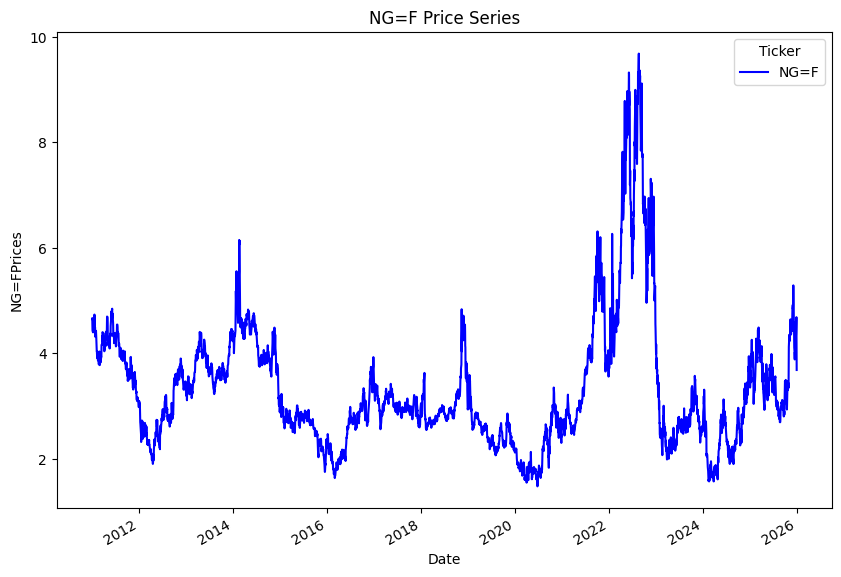

In [ ]:
data.Close.plot(figsize=(10,7),color='b')
plt.ylabel("{}Prices".format(stocks))
plt.title("{} Price Series".format(stocks))
plt.show()

/tmp/ipykernel_7226/2693321050.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["Close"])


<Axes: ylabel='Density'>

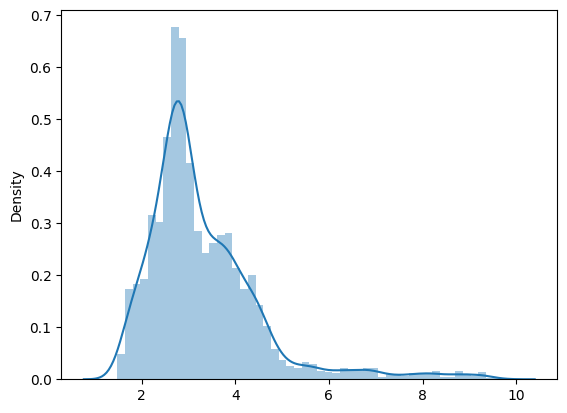

In [ ]:
sns.distplot(data["Close"])

/tmp/ipykernel_7226/3218051027.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["Open"])


<Axes: ylabel='Density'>

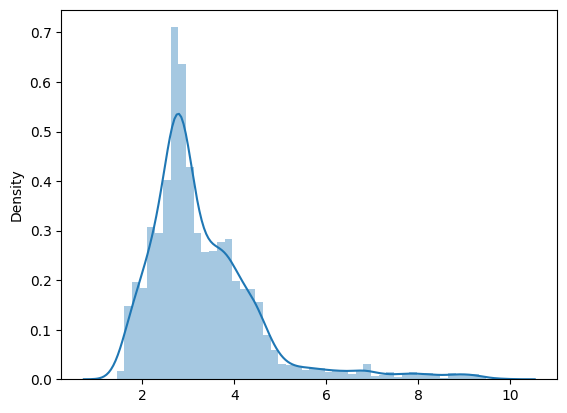

In [ ]:
sns.distplot(data["Open"])

/tmp/ipykernel_7226/3277148864.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["High"])


<Axes: ylabel='Density'>

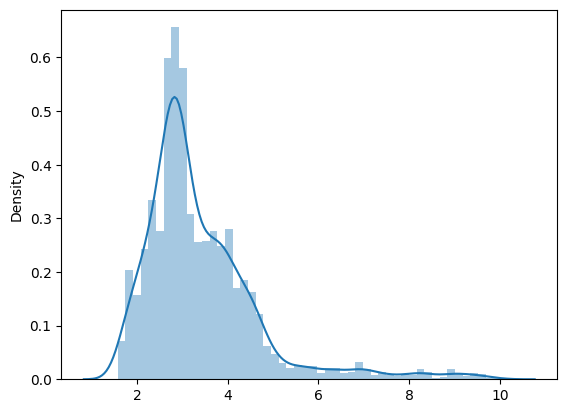

In [ ]:
sns.distplot(data["High"])

/tmp/ipykernel_7226/1748125048.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["Low"])


<Axes: ylabel='Density'>

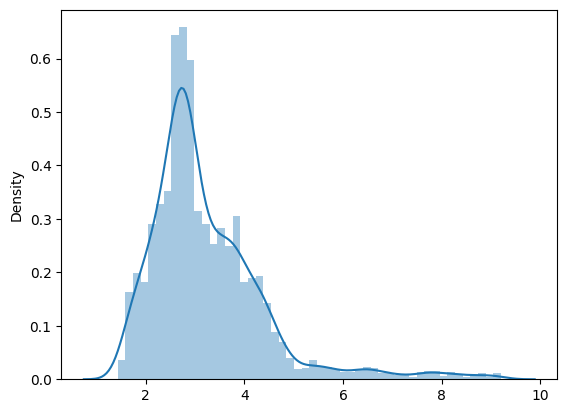

In [ ]:
sns.distplot(data["Low"])

In [ ]:
X = data.drop("Close",axis=1)
Y = data["Close"]

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=0)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(3018, 4)
(755, 4)
(3018, 1)
(755, 1)


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,Y_train)

predict = lr.predict(X_test)

In [ ]:
#MSE --> MEan Square Error
# RMSE --> sqrt(MSE)
#r2_square -->

from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
def calculate_metrics(y_test,y_pred):
  mse=mean_squared_error(y_test,y_pred)
  rmse = np.sqrt(mse)
  r2_scors = r2_score(y_test, y_pred)


  print("MSE:-", mse)
  print("RMSE:-", rmse)
  print("R2-Scors:-", r2_scors)

calculate_metrics(Y_test,predict)

MSE:- 0.0027394446633297784
RMSE:- 0.05233970446353111
R2-Scors:- 0.9980124914056898


In [ ]:
from sklearn.linear_model import Lasso, Ridge

las = Lasso().fit(X_train, Y_train)
rid = Ridge().fit(X_train, Y_train)

las_p = las.predict(X_test)
rid_p = rid.predict(X_test)

In [ ]:
calculate_metrics(Y_test,las_p)

MSE:- 0.5402995370122462
RMSE:- 0.7350507037016196
R2-Scors:- 0.6080045026321508


In [ ]:
calculate_metrics(Y_test,rid_p)

MSE:- 0.002777860063720981
RMSE:- 0.05270540829669172
R2-Scors:- 0.9979846204508742


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

params = {'C' : [0.1,1,10,100,1000],
          'gamma' : [1,0.1,0.01,0.001,0.0001],
          'kernel' :['rbf']
          }
grid = GridSearchCV(SVR(), params, refit=True, verbose=3)

grid.fit(X_train,Y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.083 total time=   0.6s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.072 total time=   0.3s


...

[CV 4/5] END .C=1000, gamma=0.0001, kernel=rbf;, score=-1.906 total time=  10.6s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 5/5] END .C=1000, gamma=0.0001, kernel=rbf;, score=-1.202 total time=  10.5s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [ ]:
svr = SVR (C=10, gamma = 0.01, kernel = 'rbf')
svr.fit(X_train, Y_train)
svr_pred = svr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
import joblib

joblib.dump(svr_pred,'model.pkl')
ridge_from_joblib = model = joblib.load('model.pkl')